In [57]:
# importing pandas for Exploratory Data Analysis

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Salary_Data.csv")

In [56]:
# exploring the data

In [ ]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [ ]:
df.isna().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

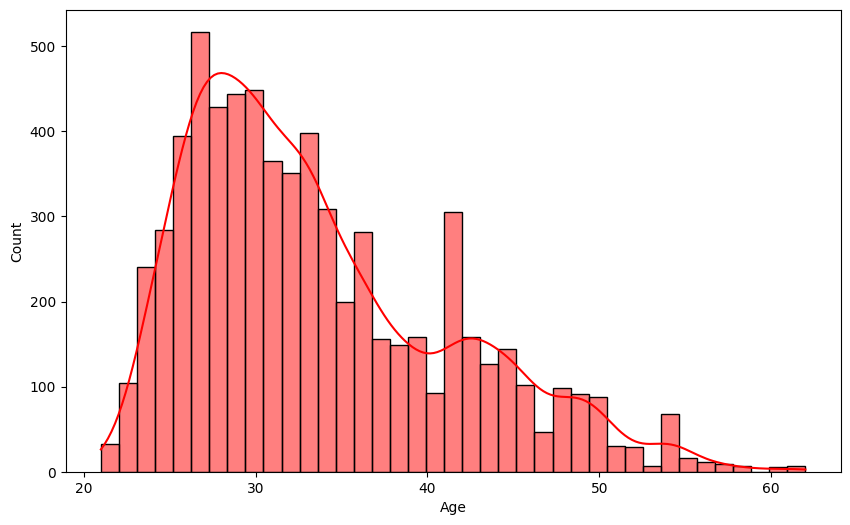

In [ ]:
plt.figure(figsize = (10,6))

sns.histplot(data = df, x = "Age", color = "red", kde = True)
plt.show()

/tmp/ipykernel_10067/264566675.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["Gender"], palette = "pastel")


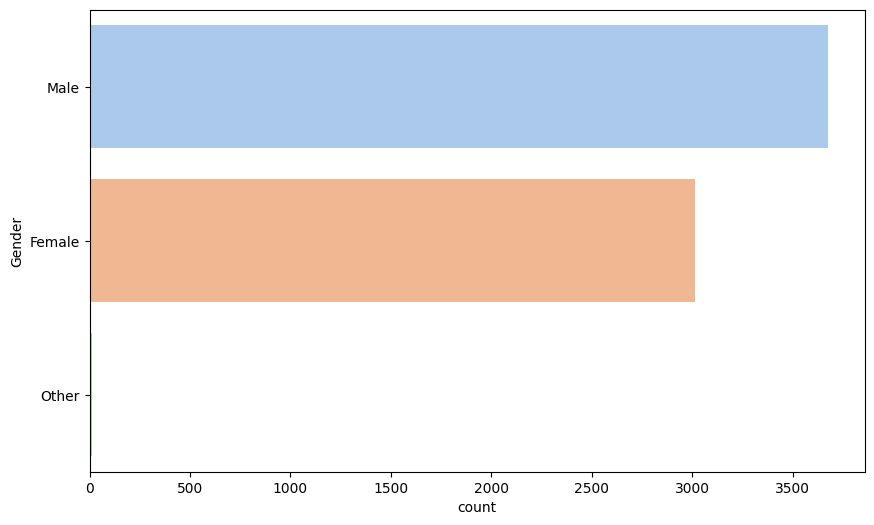

In [ ]:
plt.figure(figsize = (10,6))

sns.countplot(df["Gender"], palette = "pastel")
plt.show()

/tmp/ipykernel_10067/315606870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["Education Level"], palette = "pastel")


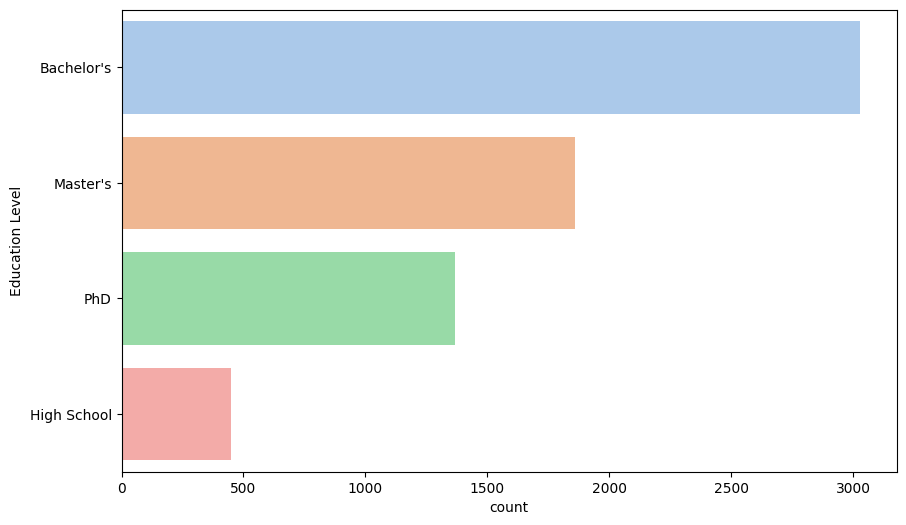

In [58]:
plt.figure(figsize = (10,6))
sns.countplot(df["Education Level"], palette = "pastel")
plt.show()


/tmp/ipykernel_10067/3753080169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["Job Title"], palette = "rocket")


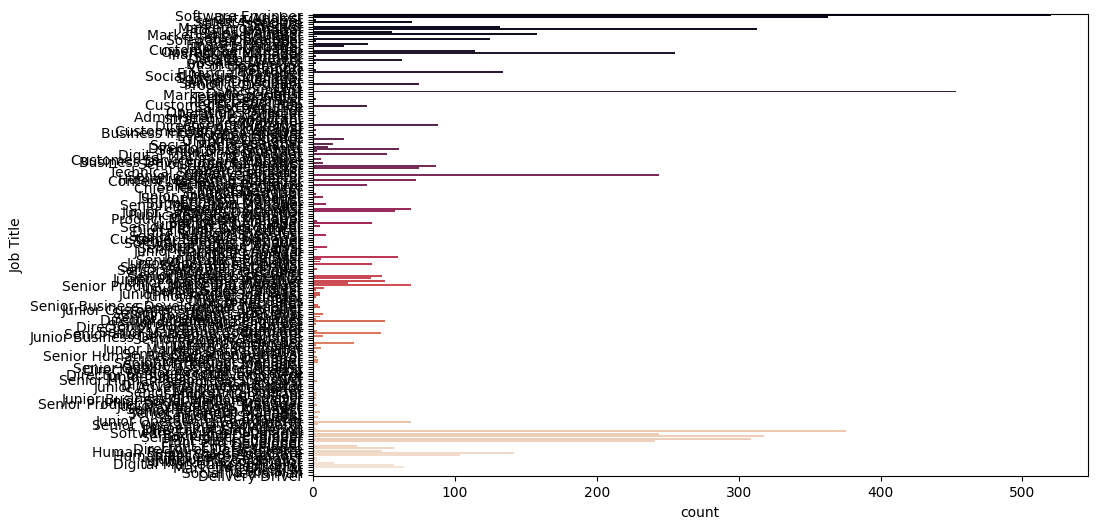

In [54]:
plt.figure(figsize = (10,6))

sns.countplot(df["Job Title"], palette = "rocket")
plt.show()

In [ ]:
df["Job Title"].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [ ]:
df["Job Title"].nunique()

193

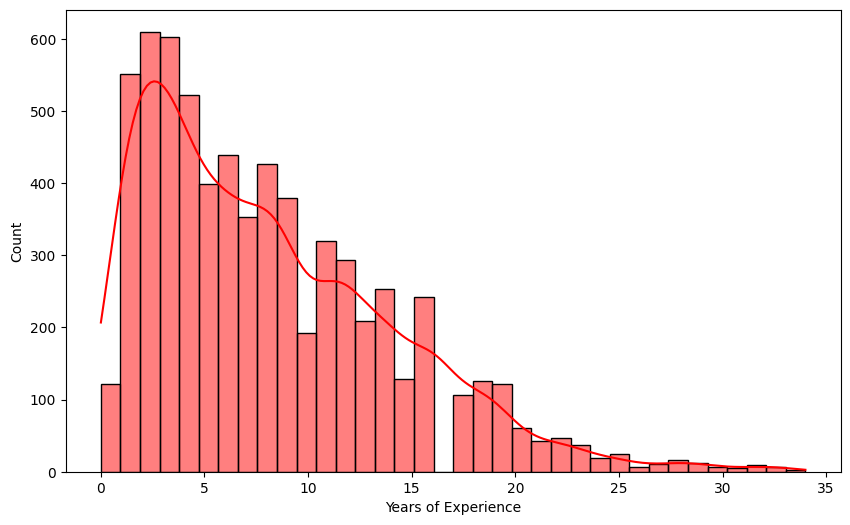

In [ ]:
plt.figure(figsize = (10,6))

sns.histplot(data = df, x = "Years of Experience", color = "red", kde = True)
plt.show()

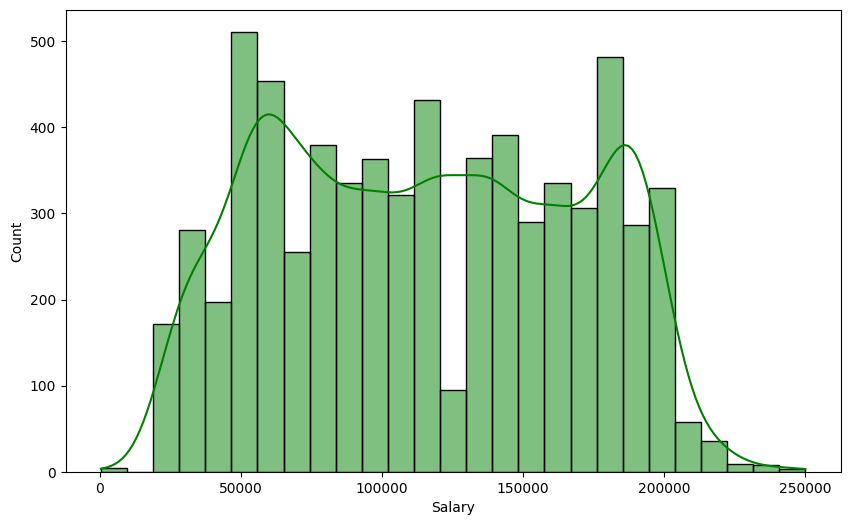

In [ ]:
plt.figure(figsize = (10,6))

sns.histplot(data = df, x = "Salary", color = "green", kde = True)
plt.show()

# Fixing Education Level column

In [ ]:
# there are duplicates of data in the education level column

In [ ]:
df["Education Level"] = df["Education Level"].replace({"Bachelor's Degree" : "Bachelor's",
                                                            "Master's Degree" : "Master's",
                                                            "phD" : "PhD"})

In [ ]:
df["Education Level"].unique()

array(["Bachelor's", "Master's", 'PhD', nan, 'High School'], dtype=object)

# Filling Age/ Gender/ Education Level/ Job title/ Years of Experience/ Salary column

In [ ]:
Age_i = df["Age"].mode()[0]

In [ ]:
df["Age"] = df["Age"].fillna(Age_i)

In [ ]:
gen_i = df["Gender"].mode()[0]
df["Gender"] = df["Gender"].fillna(gen_i)

In [ ]:
ed_i= df["Education Level"].mode()[0]
df["Education Level"] = df["Education Level"].fillna(ed_i)

In [ ]:
job_i= df["Job Title"].mode()[0]
df["Job Title"] = df["Job Title"].fillna(job_i)

In [ ]:
yoe_i= df["Years of Experience"].mode()[0]
df["Years of Experience"] = df["Years of Experience"].fillna(yoe_i)

In [ ]:
salary_i = df["Salary"].mean()
df["Salary"] = df["Salary"].fillna(salary_i)

In [ ]:
df.isna().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [ ]:
df.to_csv('cleaned_data.csv', index=False)

print("File saved successfully!")

File saved successfully!


#  Encoding

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns = "Salary")
y = df["Salary"]

In [ ]:
num_col = ["Age", "Years of Experience"]
cat_col = ["Gender", "Job Title", "Education Level"]

In [ ]:
# using simple imputer to prevent data leakage

In [ ]:
num_transformer = Pipeline(steps = [("imputer" , SimpleImputer(strategy="most_frequent")),
 ("scaler", StandardScaler())])

cat_transformer = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('onehot' , OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num' , num_transformer , num_col),
        ('cat' , cat_transformer , cat_col)
    ]
)

In [ ]:
# model = Gradient Boosting Regressor

In [ ]:
model_pipeline = Pipeline(steps=[
    ("Preprocess" , preprocessor),
    ("model" , GradientBoostingRegressor(random_state=42))
])

In [ ]:
X_train ,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Years of Experience']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Job Title',
                                                   'Education Level'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [ ]:
y_train_mean = y_train.mean()


In [ ]:
y_train = y_train.fillna(y_train_mean)
y_test = y_test.fillna(y_train_mean)

In [ ]:
y_pred = model_pipeline.predict(X_test)

In [ ]:
y_pred

array([177486.96751453, 128239.32176149,  83041.39783912, ...,
       128845.7879188 , 174095.85368653, 169058.07012634])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [ ]:
mse = mean_squared_error(y_pred,y_test)
mse

243436166.34210345

In [ ]:
mae = mean_absolute_error(y_pred,y_test)
mae

11549.664390865677

In [ ]:
r2 = r2_score(y_pred,y_test)
r2

0.8956638713407787

In [ ]:
rmse = root_mean_squared_error(y_pred,y_test)
rmse

15602.441037930681

In [ ]:
# import joblib

# # Replace 'model' with your actual trained model variable name
# joblib.dump(model_pipeline, 'salary_predictor_gradient_model.pkl')

# # Trigger the download to your local machine
# from google.colab import files
# files.download('salary_predictor_gradient_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# import sklearn
# print(sklearn.__version__)

1.6.1
